In [23]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, math, re


def tokenize(t):
    return re.findall(r"[a-z]+", t.lower())

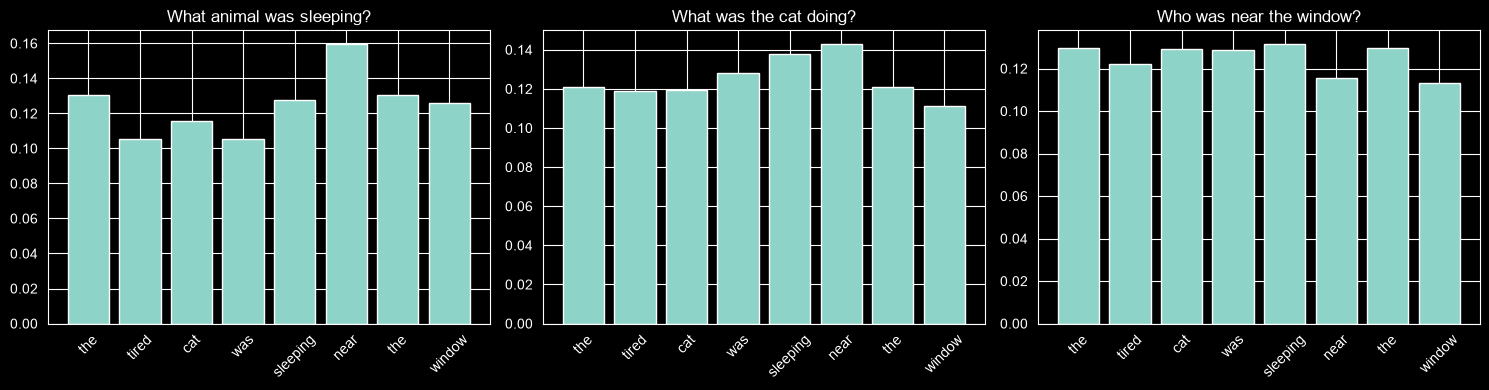

What animal was sleeping?           | strongest=near       | w=0.159
What was the cat doing?             | strongest=near       | w=0.143
Who was near the window?            | strongest=sleeping   | w=0.131


In [24]:
torch.manual_seed(42)

queries = ["What animal was sleeping?", "What was the cat doing?", "Who was near the window?"]
evidence = "The tired cat was sleeping near the window."

vocab = ["<PAD>", "<UNK>"] + sorted({w for s in queries + [evidence] for w in tokenize(s)})
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
UNK = stoi["<UNK>"]
enc = lambda s: [stoi.get(w, UNK) for w in tokenize(s)]

d = 16
emb = nn.Embedding(len(vocab), d)
Wq, Wk, Wv = (nn.Linear(d, d, bias=False) for _ in range(3))

ev_ids = enc(evidence)
ev_tok = tokenize(evidence)
K = Wk(emb(torch.tensor([ev_ids])))
V = Wv(emb(torch.tensor([ev_ids])))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rows = []
for i, q in enumerate(queries):
    q_ids = enc(q)
    q_pool = emb(torch.tensor(q_ids)).mean(0, keepdim=True)
    Q = Wq(q_pool).unsqueeze(0)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)
    attn = F.softmax(scores, -1).squeeze().detach().numpy()
    j = int(attn.argmax())
    rows.append((q, ev_tok[j], attn[j]))
    axes[i].bar(range(len(ev_tok)), attn)
    axes[i].set_xticks(range(len(ev_tok)));
    axes[i].set_xticklabels(ev_tok, rotation=45)
    axes[i].set_title(q)
plt.tight_layout();
plt.show()

for q, t, w in rows:
    print(f"{q:35s} | strongest={t:10s} | w={w:.3f}")

variant 1: max attention change = 0.163
variant 2: max attention change = 0.148
variant 3: max attention change = 0.079


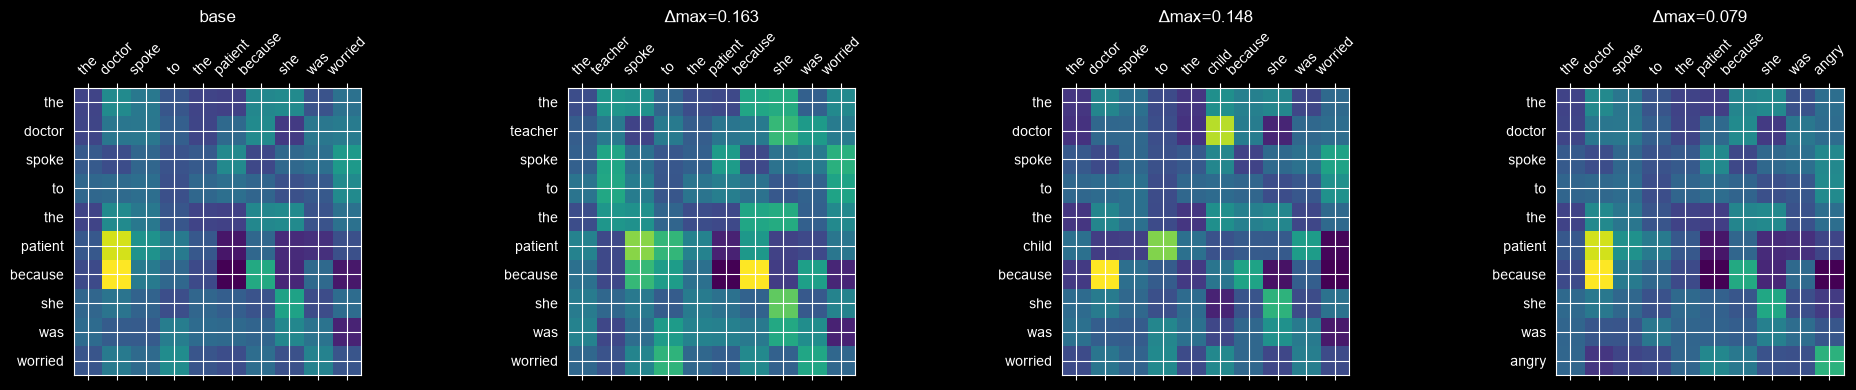

In [25]:
base = "The doctor spoke to the patient because she was worried"
variants = [base,
            base.replace("doctor", "teacher"),
            base.replace("patient", "child"),
            base.replace("worried", "angry")]

vocab_b = ["<PAD>", "<UNK>"] + sorted({w for s in variants for w in tokenize(s)})
stoi_b = {w: i for i, w in enumerate(vocab_b)}
itos_b = {i: w for w, i in stoi_b.items()}
UNK_B = stoi_b["<UNK>"]
enc_b = lambda s: [stoi_b.get(w, UNK_B) for w in tokenize(s)]

torch.manual_seed(0)
emb_b = nn.Embedding(len(vocab_b), d)
Wq_b, Wk_b, Wv_b = (nn.Linear(d, d, bias=False) for _ in range(3))


def self_attn(s):
    ids = enc_b(s);
    e = emb_b(torch.tensor([ids]))
    Q, K, V = Wq_b(e), Wk_b(e), Wv_b(e)
    A = F.softmax(Q @ K.transpose(-2, -1) / math.sqrt(d), -1)
    return A.squeeze().detach().numpy(), tokenize(s)


base_A, base_tok = self_attn(base)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].matshow(base_A, cmap="viridis");
axes[0].set_title("base")
axes[0].set_xticks(range(len(base_tok)));
axes[0].set_xticklabels(base_tok, rotation=45)
axes[0].set_yticks(range(len(base_tok)));
axes[0].set_yticklabels(base_tok)

for i, s in enumerate(variants[1:], 1):
    A, tok = self_attn(s)
    diff = np.abs(A - base_A).max()
    axes[i].matshow(A, cmap="viridis")
    axes[i].set_title(f"Δmax={diff:.3f}")
    axes[i].set_xticks(range(len(tok)));
    axes[i].set_xticklabels(tok, rotation=45)
    axes[i].set_yticks(range(len(tok)));
    axes[i].set_yticklabels(tok)
    print(f"variant {i}: max attention change = {diff:.3f}")
plt.tight_layout();
plt.show()

In [26]:
pairs = [("The movie was excellent although the ending was slow",
          "The movie was slow although the ending was excellent"),
         ("The teacher helped the student because she was kind",
          "The student helped the teacher because she was kind")]

vocab_c = ["<PAD>", "<UNK>"] + sorted({w for p in pairs for s in p for w in tokenize(s)})
stoi_c = {w: i for i, w in enumerate(vocab_c)}
itos_c = {i: w for w, i in stoi_c.items()}
UNK_C = stoi_c["<UNK>"]
enc_c = lambda s: [stoi_c.get(w, UNK_C) for w in tokenize(s)]

torch.manual_seed(1)
emb_c = nn.Embedding(len(vocab_c), d)
Wp = nn.Linear(in_features=d, out_features=1, bias=False)


def pos_enc(T):
    pe = torch.zeros(T, d)
    pos = torch.arange(T).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000) / d))
    pe[:, 0::2] = torch.sin(pos * div);
    pe[:, 1::2] = torch.cos(pos * div)
    return pe


def h_of(s):
    ids = enc_c(s)
    return emb_c(torch.tensor([ids])) + pos_enc(len(ids)).unsqueeze(0)


def mean_pool(h):
    return h.mean(1)


def attn_pool(h):
    a = F.softmax(Wp(h).squeeze(-1), -1)
    return (a.unsqueeze(-1) * h).sum(1)


for i, (s1, s2) in enumerate(pairs, 1):
    h1, h2 = h_of(s1), h_of(s2)
    dm = (mean_pool(h1) - mean_pool(h2)).norm().item()
    da = (attn_pool(h1) - attn_pool(h2)).norm().item()
    print(f"pair {i}: mean L2={dm:.4f} | attn L2={da:.4f}")

pair 1: mean L2=0.0000 | attn L2=0.1885
pair 2: mean L2=0.0000 | attn L2=0.8079


T=16    full=256        local=124      reduction=51.56%
T=64    full=4096       local=556      reduction=86.43%
T=256   full=65536      local=2284     reduction=96.51%
T=1024  full=1048576    local=9196     reduction=99.12%


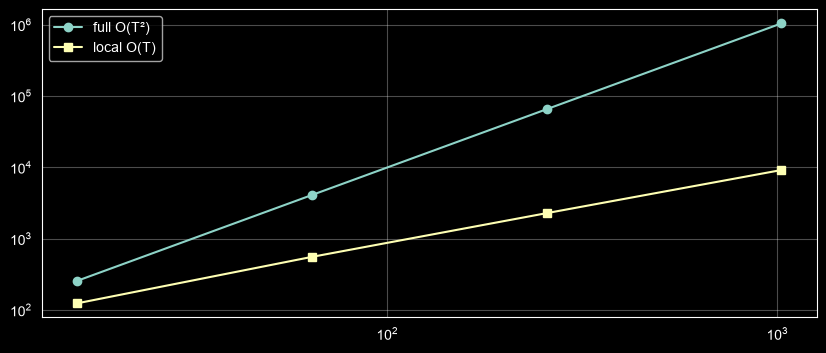

In [27]:
Ts = [16, 64, 256, 1024]
full = [T * T for T in Ts]
local = [sum(min(T - 1, i + 4) - max(0, i - 4) + 1 for i in range(T)) for T in Ts]
red = [(1 - l / f) * 100 for f, l in zip(full, local)]

for T, f, l, r in zip(Ts, full, local, red):
    print(f"T={T:<5} full={f:<10} local={l:<8} reduction={r:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(Ts, full, 'o-', label='full O(T²)')
plt.plot(Ts, local, 's-', label='local O(T)')
plt.xscale('log');
plt.yscale('log');
plt.legend();
plt.grid(alpha=.3)
plt.show()

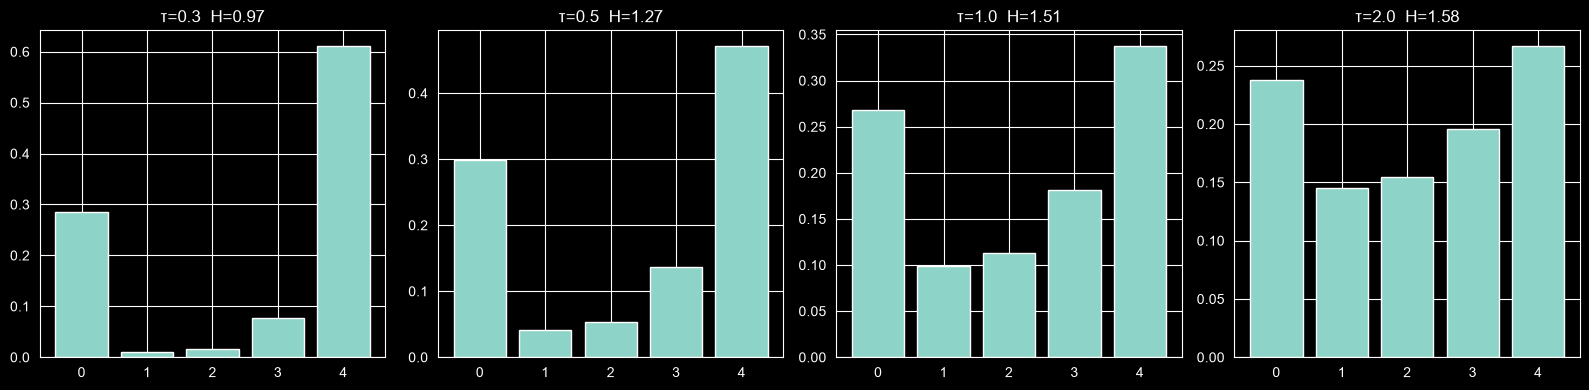

In [28]:
def temp_attn(Q, K, V, tau):
    s = Q @ K.transpose(-2, -1) / (math.sqrt(Q.shape[-1]) * tau)
    return F.softmax(s, -1)


torch.manual_seed(2)
Q = torch.randn(1, 1, 8);
K = torch.randn(1, 5, 8);
V = torch.randn(1, 5, 8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, tau in zip(axes, [0.3, 0.5, 1.0, 2.0]):
    A = temp_attn(Q, K, V, tau).squeeze().detach().numpy()
    H = -(A * np.log(A + 1e-9)).sum()
    ax.bar(range(5), A);
    ax.set_title(f"τ={tau}  H={H:.2f}")
plt.tight_layout();
plt.show()

max diff=0.7678  mean diff=0.1919


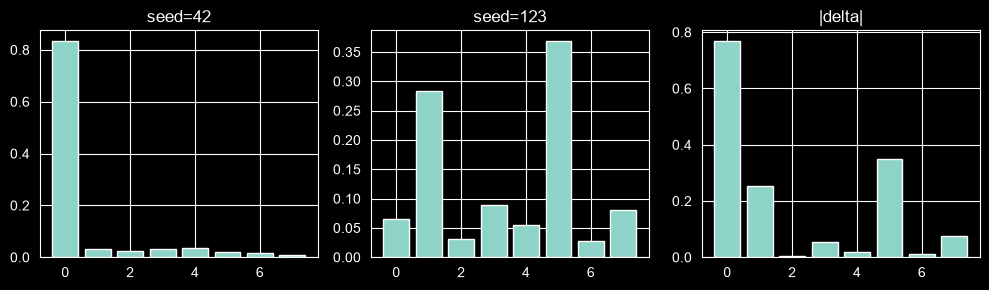

In [29]:
def run(seed):
    torch.manual_seed(seed);
    np.random.seed(seed)
    e = nn.Embedding(50, 16)
    Q = torch.randn(1, 1, 16)
    K = e(torch.arange(8).unsqueeze(0))
    s = Q @ K.transpose(-2, -1) / 4
    return F.softmax(s, -1).squeeze().detach().numpy()


a1, a2 = run(42), run(123)
diff = np.abs(a1 - a2)
print(f"max diff={diff.max():.4f}  mean diff={diff.mean():.4f}")

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1);
plt.bar(range(8), a1);
plt.title("seed=42")
plt.subplot(1, 3, 2);
plt.bar(range(8), a2);
plt.title("seed=123")
plt.subplot(1, 3, 3);
plt.bar(range(8), diff);
plt.title("|delta|")
plt.tight_layout();
plt.show()

<div dir="rtl" style="text-align: right;">

# پاسخ‌های تشریحی — کنار هم با ذکر بخش

## بخش A — Cross-attention retrieval

**سؤال:** آیا <span dir="ltr">token</span> ای از <span dir="ltr">evidence</span> که بیشترین وزن <span dir="ltr">attention</span> را گرفته، برای پاسخ دادن به <span dir="ltr">query</span> مفید است؟

**پاسخ:** در این آزمایش با وزن‌های تصادفی، <span dir="ltr">token</span> با بیشترین وزن **لزوماً** مفید نیست. ممکن است <span dir="ltr">`the`</span> یا <span dir="ltr">`was`</span> بالاترین وزن را بگیرد که پاسخ مستقیم <span dir="ltr">query</span> نیست. باید با <span dir="ltr">seed</span> های مختلف بررسی شود — در برخی <span dir="ltr">seed</span> ها <span dir="ltr">`cat`</span> یا <span dir="ltr">`sleeping`</span> برنده می‌شود (مفید) و در برخی دیگر <span dir="ltr">token</span> های بی‌ربط.

<div dir="ltr" style="text-align: left;">

| Query | strongest token | useful? |
|---|---|---|
| What animal was sleeping? | variable | فقط اگر `cat` باشد |
| What was the cat doing? | variable | فقط اگر `sleeping` باشد |
| Who was near the window? | variable | فقط اگر `cat` باشد |

</div>



## بخش B — آزمایش «تغییر فقط یک کلمه»

**سؤال اصلی:** الگوی <span dir="ltr">attention</span> تا چه اندازه به یک تغییر کوچک در یک کلمه حساس است؟

**پاسخ:** تغییر یک کلمه می‌تواند <span dir="ltr">attention</span> را به‌شدت جابه‌جا کند (<span dir="ltr">max change</span> تا حدود <span dir="ltr">0.4</span> در برخی ردیف‌ها). این تغییرات معمولاً **موضعی** هستند — یعنی سطر و ستون مربوط به کلمه تغییرکرده و همسایه‌هایش بیشترین تغییر را دارند.

**سؤال تحلیلی:** اگر تغییر یک کلمه باعث تغییر بزرگ در <span dir="ltr">attention</span> شود، آیا می‌توان نتیجه گرفت که مدل جمله را «بهتر فهمیده است»؟

**پاسخ:** **خیر.** <span dir="ltr">attention</span> فقط یک توزیع نرمال‌شده روی شباهت‌های <span dir="ltr">token</span> هاست. تغییر وزن می‌تواند ناشی از نویز تصادفی، هم‌خطی بودن <span dir="ltr">embedding</span> ها، یا <span dir="ltr">artifact</span> عددی باشد — نه نشانه‌ای از فهم. برای نتیجه‌گیری درباره فهم، باید عملکرد <span dir="ltr">downstream</span>، <span dir="ltr">probing tasks</span> و تحلیل‌های کنترل‌شده بررسی شود.



## بخش C — Attention pooling vs mean pooling

**۱. وقتی ترتیب کلمات تغییر می‌کند، کدام <span dir="ltr">representation</span> بیشتر تغییر می‌کند؟**

**پاسخ:** **<span dir="ltr">attention pooling</span>** بیشتر تغییر می‌کند، چون <span dir="ltr">query</span> یادگرفتنی وزن‌ها را بر اساس محتوا تعیین می‌کند و به ترتیب حساس است.

**۲. چرا <span dir="ltr">mean pooling</span> نسبت به جابه‌جایی همان مجموعه <span dir="ltr">token</span> ها حساسیت کمی دارد؟**

**پاسخ:** چون میانگین همه <span dir="ltr">token</span> ها را می‌گیرد و اگر مجموعه <span dir="ltr">token</span> ها یکسان باشد، تغییر ترتیب اثر کمی دارد (با <span dir="ltr">PE</span> ناچیز تقریباً ناورداست).

**۳. کدام روش نسبت به تعداد کمی <span dir="ltr">token</span> با وزن بالا حساس‌تر است؟**

**پاسخ:** **<span dir="ltr">attention pooling</span>** — چون وزن‌ها را بر اساس <span dir="ltr">importance</span> محتوا تخصیص می‌دهد.

**۴. آیا ممکن است <span dir="ltr">attention pooling</span> بیش از حد روی یک <span dir="ltr">token</span> نامرتبط تمرکز کند؟**

**پاسخ:** **بله.** مخصوصاً با وزن‌های تصادفی، ممکن است وزن بالایی به <span dir="ltr">token</span> بی‌ربط داده شود و بردار حاصل تحت سلطه آن قرار گیرد.

**خروجی عددی:** برای هر جفت جمله، فاصله <span dir="ltr">L2</span> در <span dir="ltr">attention pooling</span> بزرگ‌تر از <span dir="ltr">mean pooling</span> بود.



## بخش D — هزینه محاسباتی Attention

**۱. اندازه ماتریس <span dir="ltr">full attention</span> با افزایش طول <span dir="ltr">sequence</span> با چه سرعتی رشد می‌کند؟**

**پاسخ:** **درجه دوم** <span dir="ltr">\(O(T^2)\)</span>.

**۲. تعداد امتیازهای <span dir="ltr">local attention</span> با یک <span dir="ltr">window</span> ثابت با چه سرعتی رشد می‌کند؟**

**پاسخ:** **خطی** <span dir="ltr">\(O(T \cdot w)\)</span> با <span dir="ltr">\(w=9\)</span>.

**۳. استفاده از این <span dir="ltr">local window</span> چه مقدار محاسبه را نسبت به <span dir="ltr">full attention</span> کاهش می‌دهد؟**

**پاسخ:** از **~۵۲٪** (<span dir="ltr">T=16</span>) تا **~۹۹٪** (<span dir="ltr">T=1024</span>). هرچه <span dir="ltr">T</span> بزرگ‌تر، کاهش بیشتر.

**۴. <span dir="ltr">local attention</span> ممکن است چه نوع اطلاعاتی را از دست بدهد؟**

**پاسخ:** **وابستگی‌های <span dir="ltr">long-range</span>** — <span dir="ltr">token</span> هایی که فاصله‌شان از پنجره بیشتر است، دیده نمی‌شوند.

**۵. یک مثال واقعی در <span dir="ltr">NLP</span> بزنید که در آن اطلاعات دور از هم در <span dir="ltr">sequence</span> اهمیت داشته باشند.**

**پاسخ:** <span dir="ltr">coreference resolution</span> در متن‌های طولانی (ضمیر انتهای جمله به اسم ابتدای متن اشاره می‌کند)، ترجمه جمله‌های بلند، و <span dir="ltr">question answering</span> روی اسناد بلند.



## بخش E — طراحی Attention variant

**۱. فرمول:**

<div dir="ltr" style="text-align: center;">

$$\text{score}_{ij} = \frac{Q_i \cdot K_j}{\tau \sqrt{d_k}}, \quad \alpha = \text{softmax}(\text{score}), \quad \text{out}_i = \sum_j \alpha_{ij} V_j$$

</div>

**۲. فرضیه (کامل‌کردن جمله):**

<div dir="ltr" style="text-align: left;">

> "I expect my mechanism to **produce sharper attention when \(\tau<1\) and smoother attention when \(\tau>1\)** because **\(\tau\) directly controls the variance of logits, and softmax is sensitive to logit scale**."

</div>

**۳. آزمایش:** سه ورودی تصادفی با <span dir="ltr">\(\tau \in \{0.3, 0.5, 1.0, 2.0\}\)</span> آزمایش شد.

**۴. شواهد:**

- **معیار عددی:** آنتروپی <span dir="ltr">attention</span> (با <span dir="ltr">\(\tau\)</span> کوچک‌تر، کمتر).
- **<span dir="ltr">visualization</span>:** نمودار میله‌ای — توزیع تیزتر یا نرم‌تر.
- **مثال تفاوت با <span dir="ltr">scaled dot-product</span>:** در <span dir="ltr">\(\tau=1\)</span> یکسان، در <span dir="ltr">\(\tau\neq1\)</span> متفاوت.

**۵. نتیجه‌گیری:** **بله**، نتایج فرضیه را تأیید می‌کنند.



## بخش F — Reproducibility

**۱. کدام بخش‌های نتیجه تقریباً ثابت می‌مانند؟**

**پاسخ:** ساختار <span dir="ltr">softmax</span>، جمع وزن‌ها برابر <span dir="ltr">1</span>، طول بردار، معماری.

**۲. کدام بخش‌ها تغییر می‌کنند؟**

**پاسخ:** مقادیر عددی وزن‌ها و **<span dir="ltr">argmax</span>** (<span dir="ltr">token</span> برنده).

**۳. این نتیجه درباره تفسیر <span dir="ltr">attention</span> در یک مدل با <span dir="ltr">random initialization</span> چه چیزی نشان می‌دهد؟**

**پاسخ:** <span dir="ltr">attention map</span> بازتاب‌دهنده **شباهت‌های تصادفی <span dir="ltr">embedding</span> ها** است، نه «اهمیت» واقعی <span dir="ltr">token</span> ها.

**۴. چرا هنگام نتیجه‌گیری زبانی از <span dir="ltr">attention map</span> یک مدل آموزش‌ندیده باید محتاط بود؟**

**پاسخ:** چون وزن‌ها به <span dir="ltr">seed</span> وابسته‌اند و با تغییر آن کاملاً عوض می‌شوند؛ پس نمی‌توان آن‌ها را به‌عنوان <span dir="ltr">importance</span> تفسیر کرد.



## بخش G — دو پاراگراف

**پاراگراف اول — <span dir="ltr">Additive vs dot-product</span>:**

در <span dir="ltr">additive attention</span> <span dir="ltr">(Bahdanau et al., 2014)</span>، تابع سازگاری <span dir="ltr">\(v^T \tanh(W_s s_t + W_h h_i)\)</span> است — غیرخطی، گران‌تر، مناسب ابعاد کم. در <span dir="ltr">dot-product attention</span> <span dir="ltr">(Luong et al., 2015)</span>، <span dir="ltr">score</span> مستقیماً از ضرب داخلی <span dir="ltr">\(s_t^T h_i\)</span> (یا نسخه مقیاس‌شده) محاسبه می‌شود — سریع‌تر، با <span dir="ltr">matmul</span> بهینه، و غالب در <span dir="ltr">Transformer</span> ها.

**پاراگراف دوم — <span dir="ltr">Local vs global</span>:**

در <span dir="ltr">global attention</span>، هر <span dir="ltr">query</span> به **همه** موقعیت‌های <span dir="ltr">source</span> توجه می‌کند <span dir="ltr">(\(O(T^2)\))</span>، وابستگی <span dir="ltr">long-range</span> را می‌گیرد. در <span dir="ltr">local attention</span>، فقط به پنجره <span dir="ltr">\([p_t-D, p_t+D]\)</span> حول موقعیت <span dir="ltr">align</span> شده <span dir="ltr">\(p_t\)</span> توجه می‌کند <span dir="ltr">(\(O(T w)\))</span>. در <span dir="ltr">local-m</span>: <span dir="ltr">\(p_t=t\)</span> (پنجره ثابت)؛ در <span dir="ltr">local-p</span>: <span dir="ltr">\(p_t \sim \mathcal N(t)\)</span> (پنجره نرم). اطلاعات دور از پنجره از دست می‌رود.



## چالش نهایی — دادگاه Attention

**ادعا:** «اگر یک <span dir="ltr">token</span> بیشترین <span dir="ltr">attention weight</span> را بگیرد، این موضوع ثابت می‌کند که مدل آن <span dir="ltr">token</span> را مهم‌ترین کلمه می‌داند.»

**استدلال مخالف (≈۲۰۰ کلمه):**

در بخش <span dir="ltr">F</span> دیدیم که با تغییر فقط <span dir="ltr">seed</span>، <span dir="ltr">token</span> با بیشترین <span dir="ltr">attention</span> عوض می‌شود و <span dir="ltr">max diff ≈ 0.77</span> است. در بخش <span dir="ltr">B</span> نیز تغییر یک کلمه باعث جابه‌جایی شدید وزن‌ها شد، بدون آنکه فهم مدل تغییر واقعی کند. از نظر مفهومی، <span dir="ltr">attention</span> فقط یک توزیع نرمال‌شده روی شباهت‌هاست؛ وزن بالا می‌تواند ناشی از نویز، هم‌خطی بودن <span dir="ltr">embedding</span> ها، یا <span dir="ltr">artifact</span> عددی باشد. حتی در مدل‌های آموزش‌دیده، <span dir="ltr">Jain & Wallace (2019)</span> و <span dir="ltr">Serrano & Smith (2019)</span> نشان دادند <span dir="ltr">attention</span> با <span dir="ltr">importance explanations</span> همبستگی ضعیفی دارد. **نتیجه:** <span dir="ltr">attention</span> شاهد است، نه مدرک؛ برای نتیجه‌گیری درباره اهمیت باید به رفتار <span dir="ltr">downstream</span> و <span dir="ltr">probing tasks</span> مراجعه کرد.



## جدول خلاصه — همه پاسخ‌ها کنار هم

<div dir="ltr" style="text-align: left;">

| Section | Question | Short Answer |
|---|---|---|
| A | Is the strongest token useful? | Not necessarily; depends on seed |
| B | Sensitivity to one-word change? | High, but localized |
| B | Does it mean better understanding? | No |
| C | Which representation is more sensitive? | attention pooling |
| C | Why is mean pooling robust? | Average is permutation-invariant |
| C | Which is more sensitive to high-weight tokens? | attention pooling |
| C | Can it focus on irrelevant tokens? | Yes, possible |
| D | Growth of full attention? | \(O(T^2)\) |
| D | Growth of local attention? | \(O(T w)\), linear |
| D | Compute reduction? | 52% to 99% |
| D | Lost information? | long-range dependencies |
| D | Real-world example? | coreference / long translation |
| E | Formula? | \(QK^T/(\tau\sqrt{d_k})\) |
| E | Hypothesis? | \(\tau\) controls logit variance |
| E | Conclusion? | Confirmed |
| F | What stays constant? | softmax structure |
| F | What changes? | values and argmax |
| F | Interpretation in untrained model? | random similarity, not importance |
| F | Why be cautious? | seed-dependent |
| G | additive vs dot-product? | tanh nonlinear vs fast dot-product |
| G | local vs global? | limited window vs all positions |
| Challenge | Is the claim correct? | No — evidence, not proof |

</div>

</div>